In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import cupy
import os

kaggle = True if os.environ.get('KAGGLE_URL_BASE','') else False
balanced = True

if kaggle:
    training_data = '/kaggle/input/competitions/playground-series-s6e4/train.csv'
else:
    training_data = 'data/train.csv'

df_tv = pd.read_csv(training_data)
continous_variables = df_tv.select_dtypes(['float64']).columns
index = [df_tv.columns.get_loc(col) for col in continous_variables]

df_dummy = pd.get_dummies(df_tv.iloc[:,1:-1], dtype=int, drop_first=True)
x = df_dummy.iloc[:,:].values
y = df_tv.iloc[:,-1].values

class_le = LabelEncoder()
y = class_le.fit_transform(y)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(x, y, 
                     test_size=0.20,
                     stratify=y,
                     random_state=1)

sc = StandardScaler().fit(X_train[:, index])
X_train[:, index] = sc.transform(X_train[:, index])
X_test[:, index] = sc.transform(X_test[:, index])


if balanced:
    majority_class = np.argmax(np.bincount(y_train))
    minority_class = np.argmin(np.bincount(y_train))
    middle_class = list(set(np.unique(y_train)) - set([majority_class, minority_class]))[0]
    X_train_majority = X_train[y_train == majority_class]
    y_train_majority = y_train[y_train == majority_class]
    
    X_train_minority = X_train[y_train == minority_class]
    y_train_minority = y_train[y_train == minority_class]
    
    X_train_middle = X_train[y_train == middle_class]
    y_train_middle = y_train[y_train == middle_class]
    
    
    X_train_minority_upsampled, y_train_minority_upsampled = resample(X_train_minority, y_train_minority,
                                                                      replace=True,
                                                                      n_samples=X_train_middle.shape[0],
                                                                      random_state=1)
    X_train_majority_downsampled, y_train_majority_downsampled = resample(X_train_majority, y_train_majority,
                                                                      replace=False,
                                                                      n_samples=X_train_middle.shape[0],
                                                                      random_state=1)
    X_train_balanced = np.vstack((X_train_majority_downsampled, X_train_middle, X_train_minority_upsampled))
    y_train_balanced = np.hstack((y_train_majority_downsampled, y_train_middle, y_train_minority_upsampled))

    perm = np.random.permutation(len(X_train_balanced))

    X_train = X_train_balanced[perm]
    y_train = y_train_balanced[perm]



In [ ]:





# df_tv = pd.read_csv(training_data)
# counts = df_tv['Irrigation_Need'].value_counts()
# continous_variables = df_tv.select_dtypes(['float64']).columns

# #balanced data set
# df_tv_majority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[0]]
# df_tv_mid = df_tv[df_tv['Irrigation_Need'] == counts.keys()[1]]
# df_tv_minority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[2]]

# # Downsample majority class
# majority_downsampled = resample(df_tv_majority, 
#                               replace=False,  # Sample without replacement
#                               n_samples=len(df_tv_mid),  # Equalize class sizes
#                               random_state=42)
# # Oversample minority class
# minority_upsampled = resample(df_tv_minority, 
#                               replace=True,  # Sample with replacement
#                               n_samples=len(df_tv_mid),  # Equalize class sizes
#                               random_state=42)
# # # Oversample mid class
# # mid_upsampled = resample(df_tv_mid, 
# #                          replace=True,  # Sample with replacement
# #                          n_samples=len(df_tv_majority),  # Equalize class sizes
# #                          random_state=42)
# #df_balanced = pd.concat([df_tv_majority, mid_upsampled, minority_upsampled])
# df_balanced = pd.concat([df_tv_mid, majority_downsampled, minority_upsampled])    
# df_tv = df_balanced if balanced else df_tv



# class_le = LabelEncoder()
# y = class_le.fit_transform(df_balanced['Irrigation_Need'].values)

# df_dummy = pd.get_dummies(df_balanced.iloc[:,1:-1], dtype=int, drop_first=True)

# sc = StandardScaler().fit(df_dummy[continous_variables])
# df_dummy[continous_variables] = sc.transform(df_dummy[continous_variables])
# x = df_dummy.to_numpy()

# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = \
#     train_test_split(x, y, 
#                      test_size=0.20,
#                      stratify=y,
#                      random_state=1)




In [2]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
def plot_confusion_matrix(y_pred, y_test):

    labels = class_le.inverse_transform(np.unique(y_pred))
    confmat = confusion_matrix(class_le.inverse_transform(y_test), 
                            class_le.inverse_transform(y_pred), 
                            sample_weight=None, normalize=None)
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
    for i in range(confmat.shape[0]):
        for j in range(confmat.shape[1]):
            ax.text(x=j, y=i, s=confmat[i, j],
                va='center', ha='center')
            ax.xaxis.set_ticks_position('bottom')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()


In [3]:
# mxgb_gs = GridSearchCV(xgb.XGBClassifier(random_state=1, tree_method='hist', device='cuda', n_jobs=-1, objective='multi:softmax', num_class=3), 
#                          param_grid={'n_estimators': [100, 500, 1000], 'learning_rate': [0.01, 0.1], 
#                                      'max_depth': [3, 4, 5, 10], 'lambda': [1, 10, 100]}, 
#                          cv=5, scoring='balanced_accuracy')

# mxgb_gs.fit(cupy.array(X_train), y_train)
# mxgb_gs.score(X_test, y_test)
mxgb = xgb.XGBClassifier(random_state=1, tree_method='hist', device='cuda', n_jobs=-1,
                        n_estimators=2000, learning_rate=0.1, max_depth=5, reg_lambda=1, 
                        objective='multi:softmax', num_class=3, eval_metric='merror')
#mxgb.fit(cupy.array(X_train), y_train)
#mxgb.score(X_test, y_test)



In [ ]:
# plot_confusion_matrix(mxgb.predict(X_test), y_test)

In [5]:
from lightgbm import LGBMClassifier
# device='cuda' is only supported in lightgbm built with: 
# pip install lightgbm --install-option=cmake.define.USE_CUDA=ON
lgbm = LGBMClassifier(class_weight="balanced", n_estimators=500, 
                      learning_rate=0.1, max_depth=5, reg_lambda=0.1,
                      boosting_type='gbdt')
#lgbm.fit(X_train, y_train)
#lgbm.score(X_test, y_test)

In [6]:
#plot_confusion_matrix(lgbm.predict(X_test), y_test)

In [7]:
from catboost import CatBoostClassifier, Pool

test_data = catboost_pool = Pool(X_test,
                                 y_test)

weights = dict(zip(class_le.transform(class_le.classes_), [.2, .2, .6]))
params = {'iterations': 2000,
          'depth': 5,
          'learning_rate': .1,
          'loss_function': 'MultiClass',
          'verbose': True,
          'task_type': 'GPU',
          'reg_lambda': 10,
          'class_weights': weights}
#cb = CatBoostClassifier(**params)
                        
#cb.fit(X_train, y_train)
#cb.score(X_test, y_test)


from sklearn.base import clone

class CustomCatBoostClassifier(CatBoostClassifier):
    def __sklearn_clone__(self):
        return CustomCatBoostClassifier(**self.get_params())
    
cb = CustomCatBoostClassifier(**params)
                        
#cb.fit(X_train, y_train)
#cb.score(X_test, y_test)

In [8]:
#plot_confusion_matrix(cb.predict(X_test), y_test)

In [9]:
# from sklearn.ensemble import VotingClassifier

# voting_clf = VotingClassifier(estimators=[('xgb', mxgb), ('lgbm', lgbm), ('cb', cb)], voting='soft')
# voting_clf.fit(X_train, y_train)
# voting_clf.score(X_test, y_test)



In [10]:
#plot_confusion_matrix(voting_clf.predict(X_test), y_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

base_models = [('xgb', mxgb), ('lgbm', lgbm), ('cb', cb)]
meta_model = LogisticRegression(max_iter=1000, multi_class="auto", solver="lbfgs")
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=2)
#stacking_clf.fit(X_train, y_train)
#stacking_clf.score(X_test, y_test)
stacking_clf.fit(x, y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010548 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2722
[LightGBM] [Info] Number of data points in the train set: 717222, number of used features: 35
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006529 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2719
[LightGBM] [Info] Number of data points in the train set: 358611, number of used features: 35
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0:	learn: 0.9644593	total: 14.1ms	remaining: 28.1s
1:	learn: 0.8625439	total: 25.5ms	remaining: 25.4s
2:	learn: 0.7769568	total: 38.5ms	remaining: 25.6s
3:	learn: 0.7062493	total: 50.4ms	remaining: 25.1s
4:	learn: 0.6483243	total: 63.1ms	remaining: 25.2s
5:	learn: 0.5942033	total: 75ms	remaining: 24.9s
6:	learn: 0.5492605	total: 87.9ms	remaining: 25s
7:	learn: 0.5096505	total: 102ms	remaining: 25.4s
8:	learn: 0.4748256	total: 113ms	remaining: 25s
9:	learn: 0.4439877	total: 124ms	remaining: 24.7s
10:	learn: 0.4165644	total: 137ms	remaining: 24.8s
11:	learn: 0.3919303	total: 160ms	remaining: 26.5s
12:	learn: 0.3704714	total: 172ms	remaining: 26.3s
13:	learn: 0.3482597	total: 186ms	remaining: 26.4s
14:	learn: 0.3299560	total: 198ms	remaining: 26.2s
15:	learn: 0.3141052	total: 208ms	remaining: 25.8s
16:	learn: 0.2995384	total: 221ms	remaining: 25.8s
17:	learn: 0.2843101	total: 234ms	remaining: 25.7s
18:	learn: 0.2716622	total: 245ms	remaining: 25.6s
19:	learn: 0.2612333	total: 258ms	remain

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,estimators,"[('xgb', ...), ('lgbm', ...), ...]"
,final_estimator,LogisticRegre..._class='auto')
,cv,2
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None


/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


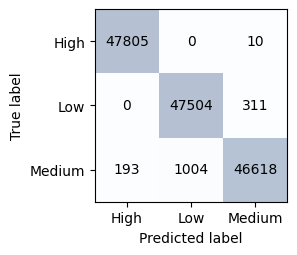

In [12]:
plot_confusion_matrix(stacking_clf.predict(X_test), y_test)

In [15]:
if kaggle:
    testing_data = '/kaggle/input/competitions/playground-series-s6e4/test.csv'
else:
    testing_data = 'data/test.csv'

df_test = pd.read_csv(testing_data)

ids = df_test['id'].values

df_test_dummy = pd.get_dummies(df_test.iloc[:,1:], drop_first=True)
df_test_dummy[continous_variables] = sc.transform(df_test_dummy[continous_variables])
x_test = df_test_dummy.to_numpy()

if kaggle:
    out_dir = '/kaggle/working/'
else:
    out_dir = 'data/'

df_submission_stack = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(stacking_clf.predict(x_test))})
df_submission_stack.to_csv(os.path.join(out_dir, 'submission-stack_v2.csv'), index=False)

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
